In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')

In [ ]:
ds_sla = xr.open_dataset('SLA_UPDATED.nc')

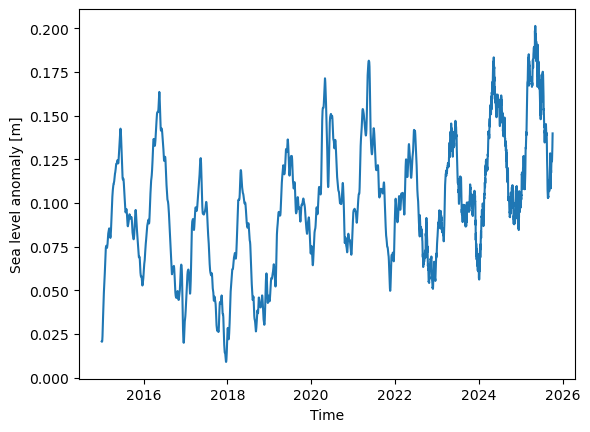

In [28]:
ds_sla.sla.mean(("latitude","longitude")).plot()

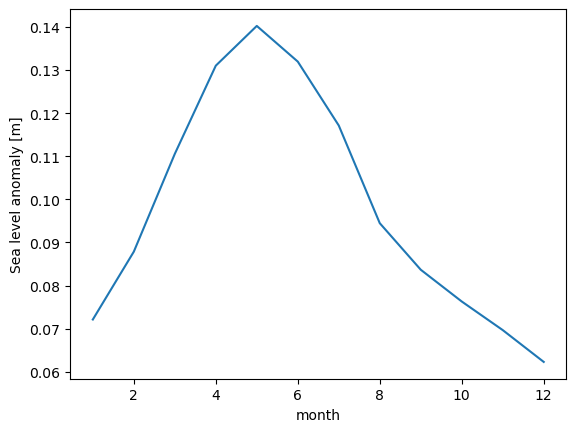

In [31]:
sla_clim = ds_sla.sla.groupby("time.month").mean()
sla_clim.mean(("latitude","longitude")).plot()

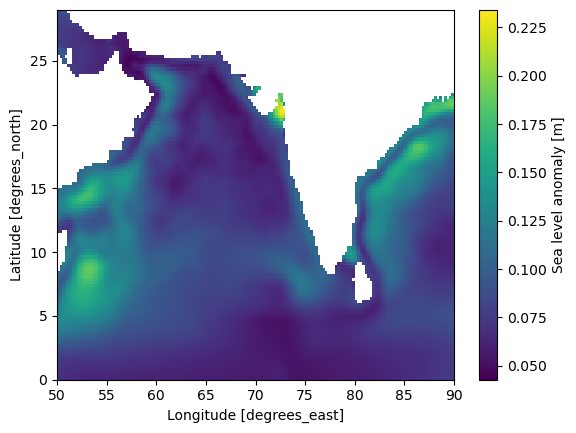

In [35]:
ds_sla.sla.std("time").plot()

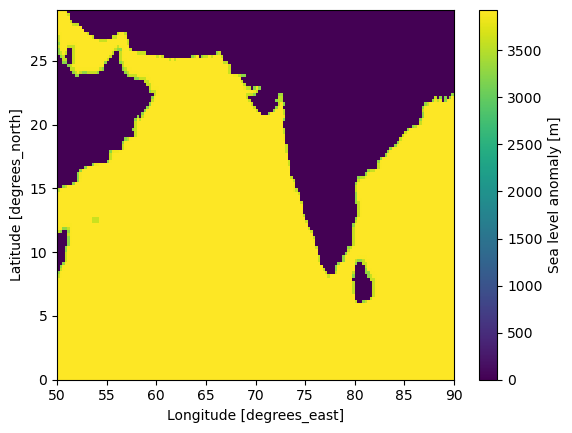

In [36]:
count_map = ds_sla.sla.count("time")

count_map.plot()

In [ ]:
vars = list(ds_gfs.data_vars)

In [5]:
lat = 17.375
lon = 83.125

In [23]:
wind = np.sqrt(ds_gfs.UGRD_10maboveground**2 + ds_gfs.VGRD_10maboveground**2)

In [24]:
sla_ts = ds_sla.sla.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

dswrf_ts = ds_gfs.DSWRF_surface.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

ulwrf_ts = ds_gfs.ULWRF_surface.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

tmp_ts = ds_gfs.TMP_surface.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

prate_ts = ds_gfs.PRATE_surface.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

dlwrf_ts = ds_gfs.DLWRF_surface.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

wind_ts = wind.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

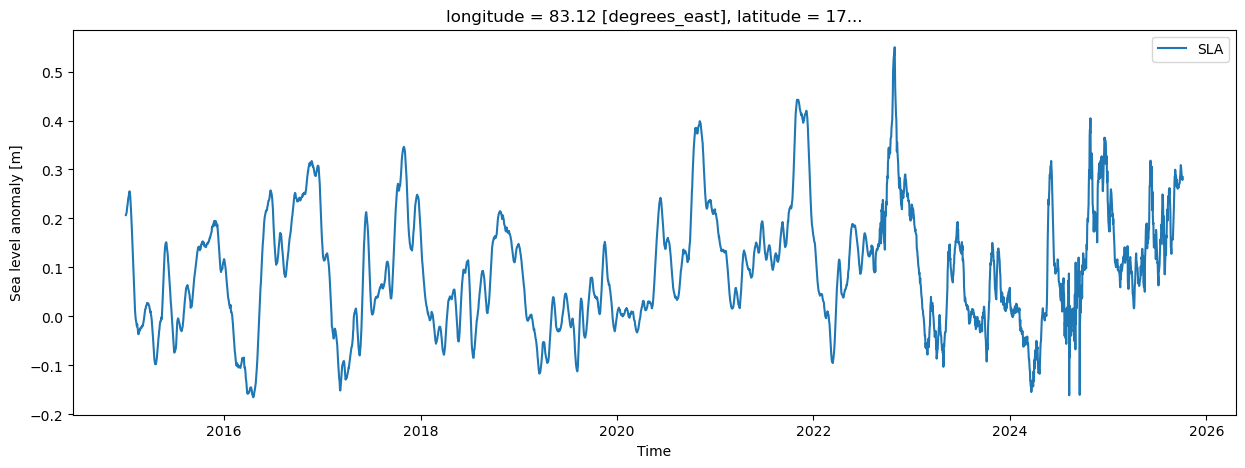

In [13]:
fig, ax = plt.subplots(figsize=(15,5))

sla_ts.plot(ax=ax, label="SLA")

ax.legend()
plt.show()

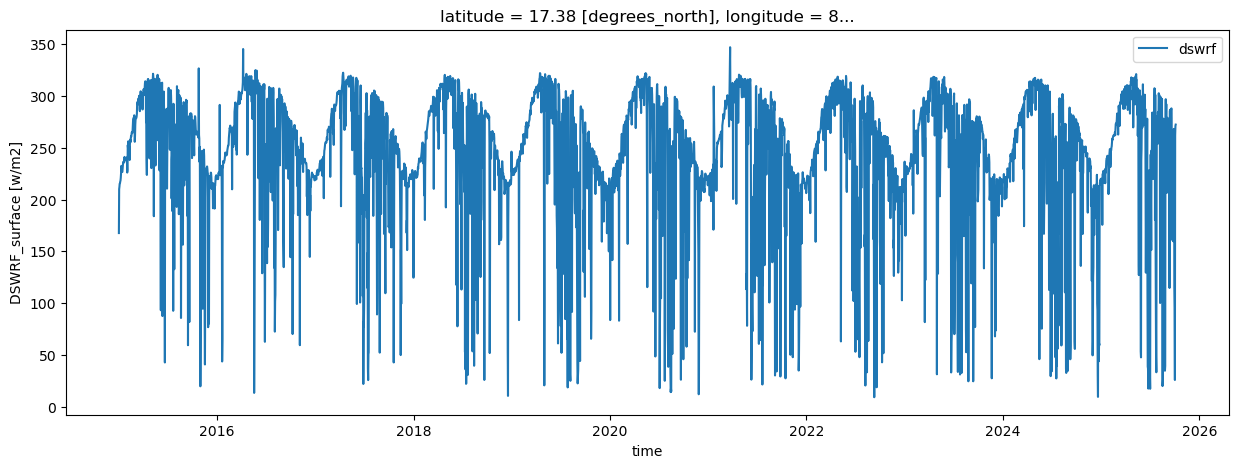

In [14]:

fig, ax = plt.subplots(figsize=(15,5))
dswrf_ts.plot(ax=ax, label="dswrf")

ax.legend()
plt.show()

In [15]:
def zscore(da):
    return (da - da.mean()) / da.std()

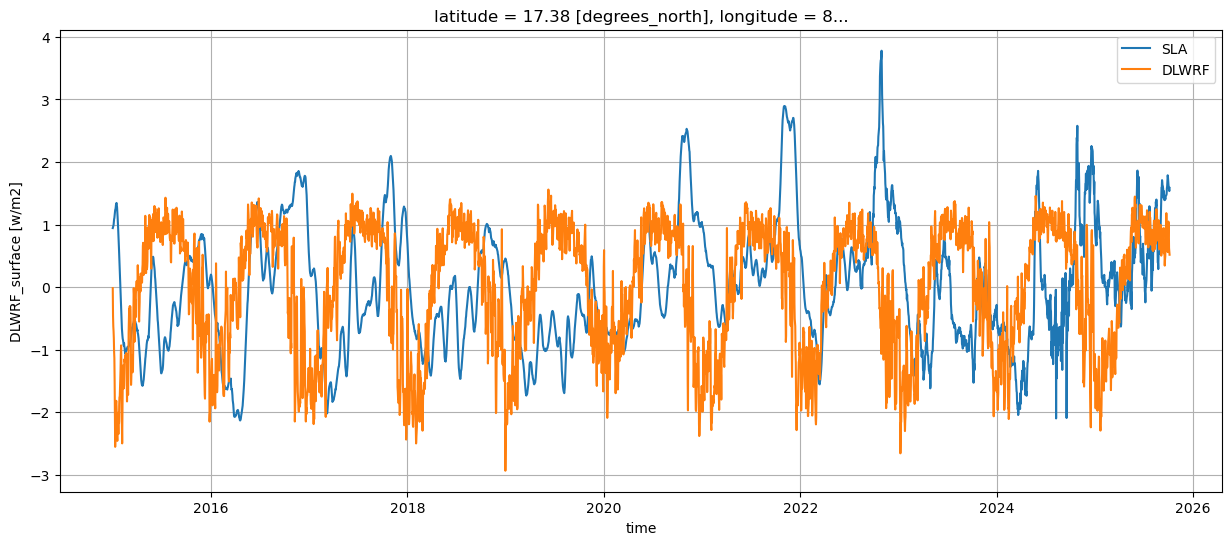

In [27]:
plt.figure(figsize=(15,6))

zscore(sla_ts).plot(label="SLA")
# zscore(ulwrf_ts).plot(label="ULWRF")
# zscore(tmp_ts).plot(label="TMP")
zscore(dlwrf_ts).plot(label="DLWRF")
# zscore(wind_ts).plot(label="wind")


plt.legend()
plt.grid()
plt.show()

In [4]:
print(ds_gfs)

<xarray.Dataset> Size: 3GB
Dimensions:              (time: 3930, latitude: 116, longitude: 160)
Coordinates:
  * time                 (time) datetime64[ns] 31kB 2015-01-01 ... 2025-10-05
  * latitude             (latitude) float32 464B 0.125 0.375 ... 28.62 28.88
  * longitude            (longitude) float32 640B 50.12 50.38 ... 89.62 89.88
Data variables:
    UGRD_10maboveground  (time, latitude, longitude) float32 292MB ...
    VGRD_10maboveground  (time, latitude, longitude) float32 292MB ...
    DSWRF_surface        (time, latitude, longitude) float32 292MB ...
    USWRF_surface        (time, latitude, longitude) float32 292MB ...
    DLWRF_surface        (time, latitude, longitude) float32 292MB ...
    ULWRF_surface        (time, latitude, longitude) float32 292MB ...
    TMP_surface          (time, latitude, longitude) float32 292MB ...
    TMP_2maboveground    (time, latitude, longitude) float32 292MB ...
    SPFH_2maboveground   (time, latitude, longitude) float32 292MB ...
   

In [5]:
print(ds_sla)

<xarray.Dataset> Size: 584MB
Dimensions:    (time: 3930, latitude: 116, longitude: 160)
Coordinates:
  * time       (time) datetime64[ns] 31kB 2015-01-01 2015-01-02 ... 2025-10-05
  * latitude   (latitude) float32 464B 0.125 0.375 0.625 ... 28.38 28.62 28.88
  * longitude  (longitude) float32 640B 50.12 50.38 50.62 ... 89.38 89.62 89.88
Data variables:
    sla        (time, latitude, longitude) float32 292MB ...
    err_sla    (time, latitude, longitude) float32 292MB ...
Attributes: (12/48)
    CDI:                             Climate Data Interface version 2.4.1 (ht...
    Conventions:                     CF-1.6
    source:                          Altimetry measurements
    institution:                     CLS, CNES
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    ...                              ...
    time_coverage_resolution:        P1D
    time_coverage_start:             2014-12-31T12:00:00Z
    title:           

In [6]:
sla_mean = ds_sla.sla.mean(dim=["latitude","longitude"])

In [8]:
for var in vars:
    corr = xr.corr(
        sla_mean,
        ds_gfs[var].mean(dim=["latitude","longitude"]),
        dim="time"
    )
    print(var, float(corr))

UGRD_10maboveground 0.36572698275001525
VGRD_10maboveground 0.4019939060810798
DSWRF_surface 0.3979099056381836
USWRF_surface 0.39677087649600634
DLWRF_surface 0.4607386791613624
ULWRF_surface 0.6036829445833519
TMP_surface 0.5999424136767456
TMP_2maboveground 0.5342907181306549
SPFH_2maboveground 0.3471805596231486
PRATE_surface 0.11810915241381598


In [9]:
for lag in range(100):
    corr = xr.corr(
        sla_mean,
        sla_mean.shift(time=lag),
        dim="time"
    )
    print(lag, float(corr))

0 0.999998857879705
1 0.9978938928456426
2 0.9963204008866982
3 0.993461646011939
4 0.9896579981002417
5 0.9857086098168509
6 0.9802700560373157
7 0.9751068430209385
8 0.9692189101382382
9 0.9632224592171323
10 0.9572321356461333
11 0.9505384068574456
12 0.9443012357144108
13 0.937770046480711
14 0.9312354021365769
15 0.9250526957509321
16 0.9184437319896898
17 0.9123141193408038
18 0.9060795019356602
19 0.899913017883091
20 0.8940180616688558
21 0.8880210915361713
22 0.8823204412030765
23 0.8764182059184187
24 0.8708038803068614
25 0.8651989482856004
26 0.8595088033855373
27 0.8539869820109395
28 0.8482678660611459
29 0.8425901040357726
30 0.8369210928272638
31 0.8312192704223711
32 0.8253569014702331
33 0.8193585443226129
34 0.8133206016335659
35 0.8071843146346602
36 0.8007473341365068
37 0.7944477644273151
38 0.7878006921493675
39 0.7812776800977997
40 0.7747054336095256
41 0.7680109220360128
42 0.7613882042589714
43 0.7545187802694692
44 0.7478156723787525
45 0.7408106525539052
46

In [10]:
sla_lag1 = ds_sla.sla.shift(time=1)
sla_lag3 = ds_sla.sla.shift(time=3)
sla_lag7 = ds_sla.sla.shift(time=7)

In [11]:
wind_speed = np.sqrt(
    ds_gfs["UGRD_10maboveground"]**2 +
    ds_gfs["VGRD_10maboveground"]**2
)

In [12]:
month = ds_sla.time.dt.month
dayofyear = ds_sla.time.dt.dayofyear

In [13]:
print(month[:10])
print(dayofyear[:10])

<xarray.DataArray 'month' (time: 10)> Size: 80B
array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Coordinates:
  * time     (time) datetime64[ns] 80B 2015-01-01 2015-01-02 ... 2015-01-10
Attributes:
    standard_name:  time
    long_name:      Time
    bounds:         time_bnds
    axis:           T
<xarray.DataArray 'dayofyear' (time: 10)> Size: 80B
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
Coordinates:
  * time     (time) datetime64[ns] 80B 2015-01-01 2015-01-02 ... 2015-01-10
Attributes:
    standard_name:  time
    long_name:      Time
    bounds:         time_bnds
    axis:           T


In [14]:
ds_sla.latitude.isel(latitude=67).item()

16.875

In [15]:
ds_sla.longitude.isel(longitude=85).item()

71.375

In [16]:
ds_sla.sla.isel(latitude=50,longitude=80).values

array([0.0314  , 0.033   , 0.0339  , ..., 0.075225, 0.077   , 0.075525],
      shape=(3930,), dtype=float32)

In [17]:
lat_idx = 67
lon_idx = 85

In [92]:
target = ds_sla.sla.shift(time=-30)

y = target.isel(
    latitude=lat_idx,
    longitude=lon_idx
)

In [93]:
sla_now = ds_sla.sla.isel(
    latitude=lat_idx,
    longitude=lon_idx
)

sla_lag1_pt = sla_lag1.isel(
    latitude=lat_idx,
    longitude=lon_idx
)

sla_lag3_pt = sla_lag3.isel(
    latitude=lat_idx,
    longitude=lon_idx
)

sla_lag7_pt = sla_lag7.isel(
    latitude=lat_idx,
    longitude=lon_idx
)

In [94]:
ds_gfs.data_vars

Data variables:
    UGRD_10maboveground  (time, latitude, longitude) float32 292MB -3.028 ......
    VGRD_10maboveground  (time, latitude, longitude) float32 292MB -6.598 ......
    DSWRF_surface        (time, latitude, longitude) float32 292MB 292.7 ... ...
    USWRF_surface        (time, latitude, longitude) float32 292MB 19.34 ... ...
    DLWRF_surface        (time, latitude, longitude) float32 292MB 391.4 ... ...
    ULWRF_surface        (time, latitude, longitude) float32 292MB 465.5 ... ...
    TMP_surface          (time, latitude, longitude) float32 292MB 300.9 ... ...
    TMP_2maboveground    (time, latitude, longitude) float32 292MB 299.6 ... ...
    SPFH_2maboveground   (time, latitude, longitude) float32 292MB 0.01619 .....
    PRATE_surface        (time, latitude, longitude) float32 292MB 1.719e-06 ...

In [95]:
tmp_surface = ds_gfs["TMP_surface"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

tmp_2m = ds_gfs["TMP_2maboveground"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

ugrd = ds_gfs["UGRD_10maboveground"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

vgrd = ds_gfs["VGRD_10maboveground"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

dswrf = ds_gfs["DSWRF_surface"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

uswrf = ds_gfs["USWRF_surface"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

dlwrf = ds_gfs["DLWRF_surface"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

ulwrf = ds_gfs["ULWRF_surface"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

spfh = ds_gfs["SPFH_2maboveground"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

prate = ds_gfs["PRATE_surface"].isel(
    latitude=lat_idx,
    longitude=lon_idx
)

In [96]:
wind = np.sqrt(
    ugrd**2 +
    vgrd**2
)

In [97]:
df = pd.DataFrame({
    "sla_now": sla_now.values,
    "sla_lag1": sla_lag1_pt.values,
    "sla_lag3": sla_lag3_pt.values,
    "sla_lag7": sla_lag7_pt.values,

    "tmp_surface": tmp_surface.values,
    "tmp_2m": tmp_2m.values,

    "ugrd": ugrd.values,
    "vgrd": vgrd.values,
    "wind": wind.values,

    "dswrf": dswrf.values,
    "uswrf": uswrf.values,
    "dlwrf": dlwrf.values,
    "ulwrf": ulwrf.values,

    "spfh": spfh.values,
    "prate": prate.values,

    "month": month.values,
    "dayofyear": dayofyear.values,

    "target": y.values
})

df = df.dropna()

In [98]:
print(df.head())
print(df.shape)

    sla_now  sla_lag1  sla_lag3  sla_lag7  tmp_surface      tmp_2m      ugrd  \
7    0.0554    0.0533    0.0532    0.0498   300.118774  298.013672 -0.330703   
8    0.0561    0.0554    0.0524    0.0506   300.120331  299.125061 -2.516328   
9    0.0590    0.0561    0.0533    0.0516   300.036102  299.568298 -3.132969   
10   0.0602    0.0590    0.0554    0.0542   300.043762  299.525391 -3.739219   
11   0.0617    0.0602    0.0561    0.0532   300.124207  299.372498 -3.392422   

        vgrd      wind       dswrf      uswrf       dlwrf       ulwrf  \
7  -5.413828  5.423919  230.156250  15.937500  351.640625  460.000000   
8  -2.997891  3.913982  227.445312  15.875000  362.984375  460.000000   
9  -3.979453  5.064735  228.750000  15.906250  360.210938  459.507812   
10 -5.784453  6.887790  233.437500  16.351562  347.023438  459.437500   
11 -5.360312  6.343617  233.203125  16.273438  351.460938  459.984375   

        spfh  prate  month  dayofyear  target  
7   0.013424    0.0      1      

In [99]:
len(df)

3893

In [100]:
split_idx = int(len(df)*0.8)

In [101]:
split_idx

3114

In [102]:
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

In [103]:
X_train = train.drop(columns=["target"])#,"sla_now","sla_lag1","sla_lag3","sla_lag7"])
y_train = train["target"]

X_test = test.drop(columns=["target"]) #,"sla_now","sla_lag1","sla_lag3","sla_lag7"])
y_test = test["target"]

In [104]:
X_train.shape

(3114, 17)

In [105]:
X_test.shape

(779, 17)

In [106]:
pred_persistence = test["sla_now"]

In [107]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_persistence = np.sqrt(
    mean_squared_error(
        y_test,
        pred_persistence
    )
)

print("Persistence RMSE:", rmse_persistence)

Persistence RMSE: 0.05201598994329581


In [108]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [109]:
pred = model.predict(X_test)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 0.05415886158295099


In [110]:
print(f"persistence: {rmse_persistence},xgb: {rmse_xgb}")

persistence: 0.05201598994329581,xgb: 0.05415886158295099


In [111]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

print(
    importance.sort_values(
        ascending=False
    )
)

dayofyear      0.400766
ulwrf          0.093528
sla_lag7       0.070695
tmp_surface    0.051123
sla_now        0.046680
spfh           0.043773
sla_lag3       0.041486
tmp_2m         0.037234
month          0.036321
uswrf          0.029463
dswrf          0.028348
dlwrf          0.026786
sla_lag1       0.024099
ugrd           0.021343
prate          0.019808
wind           0.015789
vgrd           0.012758
dtype: float32


In [112]:
target_lat = 17.0
target_lon = 70

In [113]:
lat_idx = np.abs(ds_sla.latitude - target_lat).argmin().item()
lon_idx = np.abs(ds_sla.longitude - target_lon).argmin().item()

print("Latitude index:", lat_idx)
print("Longitude index:", lon_idx)

print("Nearest latitude:", ds_sla.latitude[lat_idx].values)
print("Nearest longitude:", ds_sla.longitude[lon_idx].values)

Latitude index: 67
Longitude index: 79
Nearest latitude: 16.875
Nearest longitude: 69.875


C:\Users\devsr\anaconda3\Lib\site-packages\xarray\core\dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
C:\Users\devsr\anaconda3\Lib\site-packages\xarray\core\dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
